In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [2]:
train = pd.read_csv('./data/train.csv')
store = pd.read_csv('./data/store.csv')

In [3]:
data = train.merge(store, on='Store', how='left')
data['StateHoliday'] = data['StateHoliday'].astype(str)

In [4]:
data = data.drop(columns=['Promo2', 'Promo2SinceWeek', "Promo2SinceYear", "PromoInterval", 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear'])
data.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0


In [5]:
data = data[data['Open'] == 1]
data = data[data['Sales'] > 0]

data['Date'] = pd.to_datetime(data['Date'])

data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['WeekOfYear'] = data['Date'].dt.isocalendar().week.astype(int)

data['CompetitionDistance'] = data['CompetitionDistance'].fillna(
    data['CompetitionDistance'].median()
)

data = data.fillna(0)

In [6]:
for col in ['StoreType','Assortment','StateHoliday']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

In [7]:
data = data.sort_values(['Store','Date'])

In [8]:
data['Average_Sales_7'] = (
    data.groupby('Store')['Sales']
    .transform(lambda x: x.rolling(7).mean())
)

data['Demand_Std_7'] = (
    data.groupby('Store')['Sales']
    .transform(lambda x: x.rolling(7).std())
)

data['Average_Sales_30'] = (
    data.groupby('Store')['Sales']
    .transform(lambda x: x.rolling(30).mean())
)

data['Demand_Std_30'] = (
    data.groupby('Store')['Sales']
    .transform(lambda x: x.rolling(30).std())
)

In [9]:
data = data.fillna(0)

In [10]:
data.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Year,Month,Day,WeekOfYear,Average_Sales_7,Demand_Std_7,Average_Sales_30,Demand_Std_30
1014980,1,3,2013-01-02,5530,668,1,0,0,1,2,0,1270.0,2013,1,2,1,0.0,0.0,0.0,0.0
1013865,1,4,2013-01-03,4327,578,1,0,0,1,2,0,1270.0,2013,1,3,1,0.0,0.0,0.0,0.0
1012750,1,5,2013-01-04,4486,619,1,0,0,1,2,0,1270.0,2013,1,4,1,0.0,0.0,0.0,0.0
1011635,1,6,2013-01-05,4997,635,1,0,0,1,2,0,1270.0,2013,1,5,1,0.0,0.0,0.0,0.0
1009405,1,1,2013-01-07,7176,785,1,1,0,1,2,0,1270.0,2013,1,7,2,0.0,0.0,0.0,0.0


In [11]:
features = [
    'Store','DayOfWeek','Promo','SchoolHoliday',
    'StateHoliday','Year','Month','Day','WeekOfYear',
    'CompetitionDistance','StoreType','Assortment',
    'Average_Sales_7', 'Average_Sales_30', 'Demand_Std_7', 'Demand_Std_30'
]

In [12]:
X = data[features]
y = data['Sales']

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.4, shuffle=False
)

In [14]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [15]:
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [16]:
y_pred = xgb_model.predict(X_val)

print("Forecast MAPE:", mean_absolute_percentage_error(y_val, y_pred))

Forecast MAPE: 0.08506277948617935


In [17]:
val_df = data.copy()[-337736:]
val_df = val_df.drop(columns=['Sales'])
val_df

,Store,DayOfWeek,Date,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Year,Month,Day,WeekOfYear,Average_Sales_7,Demand_Std_7,Average_Sales_30,Demand_Std_30
610904,670,2,2013-12-31,548,1,0,0,1,0,0,2060.0,2013,12,31,1,6929.857143,2286.075854,7461.533333,2053.043859
608674,670,4,2014-01-02,673,1,0,0,1,0,0,2060.0,2014,1,2,1,6664.000000,2278.251376,7448.466667,2061.814764
607559,670,5,2014-01-03,677,1,0,0,1,0,0,2060.0,2014,1,3,1,5938.714286,1203.510935,7464.333333,2048.073129
606444,670,6,2014-01-04,551,1,0,0,0,0,0,2060.0,2014,1,4,1,5932.857143,1210.063969,7421.800000,2091.589206
603099,670,2,2014-01-07,1021,1,1,0,0,0,0,2060.0,2014,1,7,2,6579.428571,2377.731402,7634.933333,2150.900981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5574,1115,1,2015-07-27,608,1,1,0,1,3,2,5350.0,2015,7,27,31,6582.000000,1914.426372,6807.466667,1626.754686
4459,1115,2,2015-07-28,500,1,1,0,1,3,2,5350.0,2015,7,28,31,6869.142857,1976.829653,6905.333333,1612.289149
3344,1115,3,2015-07-29,473,1,1,0,1,3,2,5350.0,2015,7,29,31,7238.714286,1820.968214,6978.600000,1594.327003
2229,1115,4,2015-07-30,502,1,1,0,1,3,2,5350.0,2015,7,30,31,7676.285714,1649.139545,7091.600000,1570.309669


In [18]:
val_df['Actual'] = y_val.values
val_df['Predicted'] = np.ceil(y_pred / 10) * 10

val_df['Error'] = val_df['Actual'] - val_df['Predicted']
val_df['APE'] = abs(val_df['Error']) / (val_df['Actual'] + 1)

val_df['Rolling_MAPE'] = (
    val_df.groupby('Store')['APE']
    .transform(lambda x: x.rolling(7).mean())
)

In [19]:
val_df['Error_Std'] = (
    val_df.groupby('Store')['Error']
    .transform(lambda x: x.rolling(7).std())
)

val_df['Forecast_Confidence'] = 1 / (1 + val_df['Error_Std'])

val_df = val_df.fillna(0)

In [20]:
val_df["Forecast_Uncertainty"] = (
    val_df["Demand_Std_7"] /
    (val_df["Predicted"] + 1)
)

In [21]:
val_df['Past_Promo_Sales'] = (
    val_df['Actual']
    .where(val_df['Promo'] == 1)
    .groupby(val_df['Store'])
    .transform(lambda x: x.shift(1).expanding().mean())
)

val_df['Past_Normal_Sales'] = (
    val_df['Actual']
    .where(val_df['Promo'] == 0)
    .groupby(val_df['Store'])
    .transform(lambda x: x.shift(1).expanding().mean())
)

val_df['Expected_Uplift'] = (
    (val_df['Past_Promo_Sales'] - val_df['Past_Normal_Sales']) /
    (val_df['Past_Normal_Sales'] + 1)
)

val_df['Current_Uplift'] = (
    (val_df['Actual'] - val_df['Average_Sales_7']) /
    (val_df['Average_Sales_7'] + 1)
)

val_df['Promotion_Abnormality'] = (
    val_df['Current_Uplift'] -
    val_df['Expected_Uplift']
)

In [22]:
val_df["Volatility_Ratio"] = (
    val_df["Demand_Std_7"] / val_df["Average_Sales_7"]
).replace([np.inf, -np.inf], 0).fillna(0)

val_df["Promo_Risk"] = (
    val_df["Promo"] * val_df["Volatility_Ratio"]
)

In [23]:
val_df["Days_Since_Last_Promo"] = (
    val_df.groupby("Store")["Promo"]
    .apply(lambda x: (~x.astype(bool)).cumsum() - 
                     (~x.astype(bool)).cumsum().where(x == 1).ffill().fillna(0))
    .reset_index(level=0, drop=True)
)

In [24]:
val_df["Volatility_Change"] = (
    val_df["Demand_Std_7"] / val_df["Demand_Std_30"]
).replace([np.inf, -np.inf], 0).fillna(0)

In [25]:
val_df["Trend_Shift"] = (
    val_df["Average_Sales_7"] - val_df["Average_Sales_30"]
)

In [26]:
val_df["Demand_Shock_Score"] = (
    val_df["Actual"] - val_df["Average_Sales_30"]
) / (val_df["Demand_Std_30"] + 1)

In [27]:
val_df["Demand_Momentum"] = (
    val_df["Average_Sales_7"] - val_df["Average_Sales_30"]
) / (val_df["Average_Sales_30"] + 1)

val_df["Demand_Spike"] = (
    val_df["Actual"] >
    val_df["Average_Sales_30"] + 2 * val_df["Demand_Std_30"]
).astype(int)

val_df["Demand_Drop"] = (
    val_df["Actual"] <
    val_df["Average_Sales_30"] - 2 * val_df["Demand_Std_30"]
).astype(int)

In [28]:
val_df["Promo_Demand_Risk"] = val_df["Promo"] * val_df["Volatility_Ratio"]
val_df["Forecast_Risk"] = (1 - val_df["Forecast_Confidence"]) * val_df["Volatility_Ratio"]

In [29]:
val_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'Year', 'Month', 'Day', 'WeekOfYear',
       'Average_Sales_7', 'Demand_Std_7', 'Average_Sales_30', 'Demand_Std_30',
       'Actual', 'Predicted', 'Error', 'APE', 'Rolling_MAPE', 'Error_Std',
       'Forecast_Confidence', 'Forecast_Uncertainty', 'Past_Promo_Sales',
       'Past_Normal_Sales', 'Expected_Uplift', 'Current_Uplift',
       'Promotion_Abnormality', 'Volatility_Ratio', 'Promo_Risk',
       'Days_Since_Last_Promo', 'Volatility_Change', 'Trend_Shift',
       'Demand_Shock_Score', 'Demand_Momentum', 'Demand_Spike', 'Demand_Drop',
       'Promo_Demand_Risk', 'Forecast_Risk'],
      dtype='object')

In [30]:
len(val_df.columns)

43

In [31]:
val_df["HALT_Label"] = (abs(val_df['Predicted'] - val_df['Actual']) > val_df['Demand_Std_7']).astype(int)

In [32]:
val_df['HALT_Label'].value_counts()

HALT_Label
0    313641
1     24095
Name: count, dtype: int64

In [33]:
val_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'Year', 'Month', 'Day', 'WeekOfYear',
       'Average_Sales_7', 'Demand_Std_7', 'Average_Sales_30', 'Demand_Std_30',
       'Actual', 'Predicted', 'Error', 'APE', 'Rolling_MAPE', 'Error_Std',
       'Forecast_Confidence', 'Forecast_Uncertainty', 'Past_Promo_Sales',
       'Past_Normal_Sales', 'Expected_Uplift', 'Current_Uplift',
       'Promotion_Abnormality', 'Volatility_Ratio', 'Promo_Risk',
       'Days_Since_Last_Promo', 'Volatility_Change', 'Trend_Shift',
       'Demand_Shock_Score', 'Demand_Momentum', 'Demand_Spike', 'Demand_Drop',
       'Promo_Demand_Risk', 'Forecast_Risk', 'HALT_Label'],
      dtype='object')

In [34]:
halt_features = [
    "Forecast_Confidence",
    "Forecast_Uncertainty",
    "Promotion_Abnormality",
    "Promo_Risk",
    "Past_Promo_Sales",
    "Past_Normal_Sales",
    "Days_Since_Last_Promo",
    "Volatility_Ratio",
    "Volatility_Change",
    "Trend_Shift",
    'Demand_Shock_Score',
    'Demand_Spike', 
    'Demand_Drop',
    "Demand_Momentum",
    "Promo_Demand_Risk",
    "Forecast_Risk",
    "Predicted",
]

In [35]:
X_halt = val_df[halt_features]
y_halt = val_df['HALT_Label']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X_halt, y_halt, test_size=0.4, random_state=42, stratify=y_halt
)

In [37]:
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

In [38]:
halt_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42
)

In [39]:
halt_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [40]:
y_prob_train = halt_model.predict_proba(X_train)[:,1]
y_pred_train = halt_model.predict(X_train)

In [41]:
y_prob = halt_model.predict_proba(X_test)[:,1]

In [42]:
y_pred = halt_model.predict(X_test)

In [43]:
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))
print("ROC-AUC:", roc_auc_score(y_train, y_prob_train))

[[162319  25865]
 [  1374  13083]]
              precision    recall  f1-score   support

           0       0.99      0.86      0.92    188184
           1       0.34      0.90      0.49     14457

    accuracy                           0.87    202641
   macro avg       0.66      0.88      0.71    202641
weighted avg       0.94      0.87      0.89    202641

ROC-AUC: 0.9565813953812858


In [44]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[107877  17580]
 [  1133   8505]]
              precision    recall  f1-score   support

           0       0.99      0.86      0.92    125457
           1       0.33      0.88      0.48      9638

    accuracy                           0.86    135095
   macro avg       0.66      0.87      0.70    135095
weighted avg       0.94      0.86      0.89    135095

ROC-AUC: 0.9486552259357717


In [45]:
fpr, tpr, threshold = roc_curve(y_test, y_pred)

In [46]:
import matplotlib.pyplot as plt

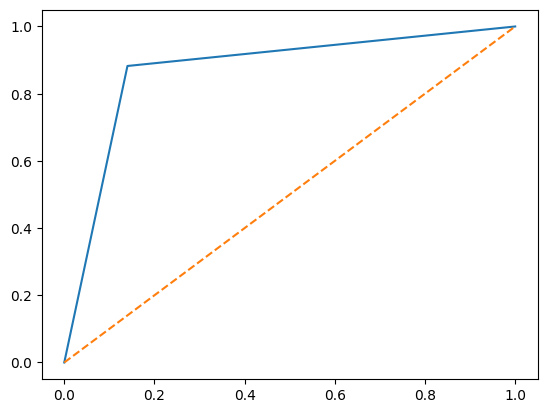

In [47]:
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")